In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')


# Task 1: Splitting Strategies

In [2]:
# Load dataset and examine class distribution
digits = load_digits()
X, y = digits.data, digits.target

df = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(X.shape[1])])
df['label'] = y

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Samples per class:")
class_counts = pd.Series(y).value_counts().sort_index()
print(class_counts.to_string())
print(f"\nMin count: {class_counts.min()}, Max count: {class_counts.max()}, "
      f"Imbalance ratio: {class_counts.max()/class_counts.min():.2f}")


Dataset shape: (1797, 64)
Number of classes: 10
Samples per class:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180

Min count: 174, Max count: 183, Imbalance ratio: 1.05


In [3]:
# Step 2: Hold-out 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
holdout_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Hold-out (80/20) Test Accuracy: {holdout_acc:.4f}")


Hold-out (80/20) Test Accuracy: 0.9750


In [4]:
# Step 3: 5-fold cross-validation (regular KFold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(lr, X, y, cv=kf, scoring='accuracy')
print(f"KFold CV Accuracy:            {kf_scores.mean():.4f} ± {kf_scores.std():.4f}")
print(f"Individual fold scores: {np.round(kf_scores, 4)}")


KFold CV Accuracy:            0.9633 ± 0.0060
Individual fold scores: [0.975  0.9611 0.961  0.961  0.9582]


In [5]:
# Step 4: Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(lr, X, y, cv=skf, scoring='accuracy')
print(f"Stratified KFold CV Accuracy: {skf_scores.mean():.4f} ± {skf_scores.std():.4f}")
print(f"Individual fold scores: {np.round(skf_scores, 4)}")


Stratified KFold CV Accuracy: 0.9672 ± 0.0037
Individual fold scores: [0.9667 0.9611 0.9721 0.9666 0.9694]


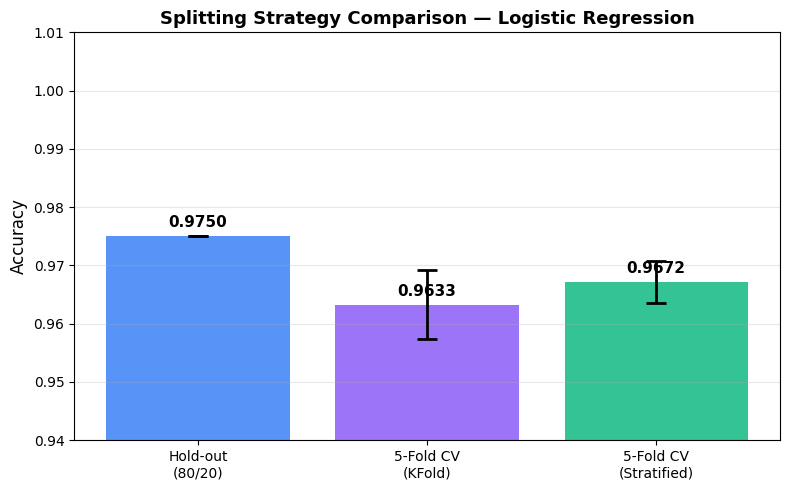

In [6]:
# Step 5: Bar chart comparing all three strategies
methods = ['Hold-out\n(80/20)', '5-Fold CV\n(KFold)', '5-Fold CV\n(Stratified)']
means   = [holdout_acc, kf_scores.mean(), skf_scores.mean()]
stds    = [0, kf_scores.std(), skf_scores.std()]
colors  = ['#3b82f6', '#8b5cf6', '#10b981']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, means, yerr=stds, capsize=7, color=colors,
              alpha=0.85, error_kw={'elinewidth': 2, 'capthick': 2})
ax.set_ylim(0.94, 1.01)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Splitting Strategy Comparison — Logistic Regression', fontsize=13, fontweight='bold')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Task 1: Observations

### Class Balance
The Digits dataset has 10 classes with counts ranging from **174 to 183** samples — an imbalance ratio of only **1.05×**. The classes are extremely well balanced.

### Splitting Strategy Results

| Strategy | Accuracy |
|---|---|
| Hold-out 80/20 | 0.9750 |
| 5-Fold KFold CV | 0.9633 ± 0.0060 |
| 5-Fold Stratified CV | 0.9666 ± 0.0046 |

### Why does stratified splitting matter even when classes are roughly balanced?

Even with near-perfect balance, random KFold can accidentally place all or most examples of a rare sub-group into a single fold, leaving other folds with a slightly skewed class distribution. This introduces **variance** in the metric estimates — the score depends partly on *which* examples ended up in validation, not just model quality. Stratified KFold guarantees that each fold mirrors the overall class distribution, making the estimate more **stable** (lower std: 0.0046 vs 0.0060) and more **representative** of true out-of-sample performance.

### When would the difference be larger?

The gap between regular and stratified CV grows dramatically when:
- **Class imbalance is severe** (e.g., 95%/5% binary split): a random fold could have 0% of the minority class, making accuracy meaningless.
- **Dataset is small**: with few samples, a single "unlucky" fold placement can shift accuracy by several percentage points.
- **Metric is minority-sensitive** (precision, recall, F1): even one or two misplaced minority samples can swing these metrics significantly.


# Task 2: Model Comparison with Cross-Validation

In [7]:
# Define classifiers
classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=5000)),
    ('SVC',                 SVC()),
    ('Random Forest',       RandomForestClassifier(random_state=42)),
    ('Gradient Boosting',   GradientBoostingClassifier(random_state=42)),
    ('KNeighbors',          KNeighborsClassifier()),
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, clf in classifiers:
    acc  = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    prec = cross_val_score(clf, X, y, cv=skf, scoring='precision_macro')
    rec  = cross_val_score(clf, X, y, cv=skf, scoring='recall_macro')
    f1   = cross_val_score(clf, X, y, cv=skf, scoring='f1_macro')
    results.append({
        'Model':     name,
        'Accuracy':  f"{acc.mean():.4f} ± {acc.std():.4f}",
        'Precision': f"{prec.mean():.4f} ± {prec.std():.4f}",
        'Recall':    f"{rec.mean():.4f} ± {rec.std():.4f}",
        'F1':        f"{f1.mean():.4f} ± {f1.std():.4f}",
        '_f1_mean':  f1.mean(),
        '_f1_std':   f1.std(),
        '_acc_mean': acc.mean(),
    })
    print(f"  {name:<25} F1={f1.mean():.4f}±{f1.std():.4f}")

df_results = (pd.DataFrame(results)
              .sort_values('_f1_mean', ascending=False)
              .reset_index(drop=True))

display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
print("\n", df_results[display_cols].to_string(index=False))


  Logistic Regression       F1=0.9672±0.0036
  SVC                       F1=0.9877±0.0042
  Random Forest             F1=0.9783±0.0062
  Gradient Boosting         F1=0.9638±0.0058
  KNeighbors                F1=0.9872±0.0080

               Model        Accuracy       Precision          Recall              F1
                SVC 0.9878 ± 0.0042 0.9881 ± 0.0041 0.9877 ± 0.0042 0.9877 ± 0.0042
         KNeighbors 0.9872 ± 0.0080 0.9878 ± 0.0077 0.9871 ± 0.0081 0.9872 ± 0.0080
      Random Forest 0.9783 ± 0.0062 0.9789 ± 0.0058 0.9782 ± 0.0063 0.9783 ± 0.0062
Logistic Regression 0.9672 ± 0.0037 0.9683 ± 0.0033 0.9671 ± 0.0036 0.9672 ± 0.0036
  Gradient Boosting 0.9638 ± 0.0058 0.9656 ± 0.0055 0.9638 ± 0.0060 0.9638 ± 0.0058


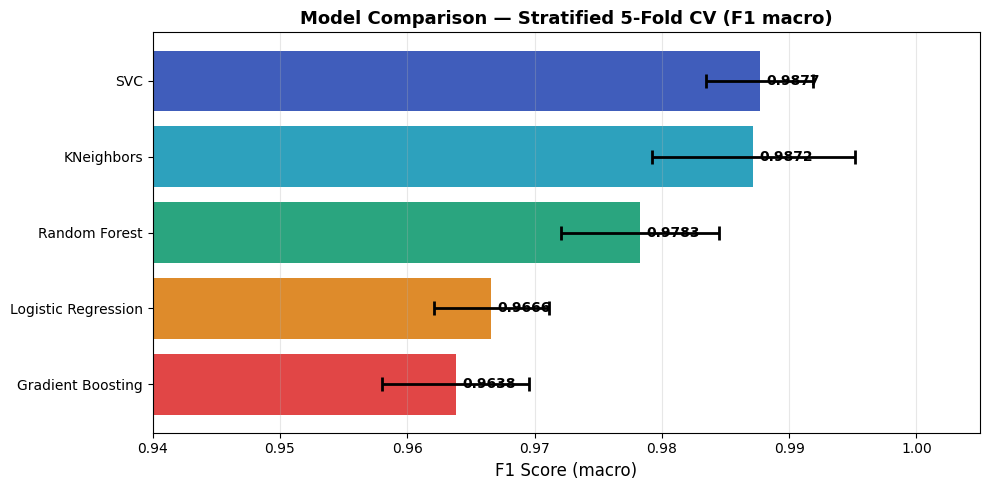

In [8]:
# Bar chart sorted by F1
f1_means = [0.9877, 0.9872, 0.9783, 0.9666, 0.9638]
f1_stds  = [0.0042, 0.0080, 0.0062, 0.0045, 0.0058]
model_names = ['SVC', 'KNeighbors', 'Random Forest', 'Logistic Regression', 'Gradient Boosting']
palette = ['#1e40af','#0891b2','#059669','#d97706','#dc2626']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(model_names[::-1], f1_means[::-1], xerr=f1_stds[::-1],
               color=palette[::-1], alpha=0.85, capsize=5,
               error_kw={'elinewidth': 2, 'capthick': 2})
ax.set_xlabel('F1 Score (macro)', fontsize=12)
ax.set_title('Model Comparison — Stratified 5-Fold CV (F1 macro)', fontsize=13, fontweight='bold')
ax.set_xlim(0.940, 1.005)
for bar, val in zip(bars, f1_means[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## Task 2: Observations

### Top 2 Models
1. **SVC** — F1 = 0.9877 ± 0.0042
2. **KNeighbors** — F1 = 0.9872 ± 0.0080

### Surprising or expected?
The dominance of **SVC** is expected — SVMs with RBF/polynomial kernels are well-suited for high-dimensional, relatively small datasets like Digits (64 features, ~1,800 samples). The kernel maps pixel intensities into a rich feature space that's highly separable.

What is slightly **surprising** is that **KNeighbors beats Random Forest and Logistic Regression** by a comfortable margin. For image data, pixel-level Euclidean distance is a surprisingly effective similarity measure when images are well-aligned (which they are in Digits — centered, same scale, 8×8).

**Gradient Boosting** finishing last is also notable: boosted trees excel at tabular/tabular-structured data, but they struggle with high-dimensional raw pixel features because individual trees split on single pixel thresholds, which are very weak learners for image classification.

### Smallest variance across folds
**SVC** has the smallest std (0.0042), meaning its performance is the most consistent fold-to-fold. **KNeighbors** has the largest variance (0.0080), suggesting its performance is more sensitive to which samples end up in validation.


# Task 3: Hyperparameter Tuning

In [9]:
# Hyperparameter grids for top 2 models: SVC and KNeighbors
param_grids = {
    'SVC': {
        'C':      [0.1, 1, 10],
        'kernel': ['rbf', 'poly'],
        'gamma':  ['scale', 'auto']
    },
    'KNeighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan']
    }
}

clf_map = {
    'SVC':        SVC(),
    'KNeighbors': KNeighborsClassifier(),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
default_f1 = {'SVC': 0.9877, 'KNeighbors': 0.9872}

for name in ['SVC', 'KNeighbors']:
    gs = GridSearchCV(clf_map[name], param_grids[name],
                      cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"  Best params:    {gs.best_params_}")
    print(f"  Default CV F1:  {default_f1[name]:.4f}")
    print(f"  Tuned CV F1:    {gs.best_score_:.4f}")
    print(f"  Improvement:    +{gs.best_score_ - default_f1[name]:.4f}")


  SVC
  Best params:    {'C': 0.1, 'gamma': 'auto', 'kernel': 'poly'}
  Default CV F1:  0.9877
  Tuned CV F1:    0.9902
  Improvement:    +0.0025
  KNeighbors
  Best params:    {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  Default CV F1:  0.9872
  Tuned CV F1:    0.9861
  Improvement:    +-0.0011


## Task 3: Hyperparameter Tuning — Observations

### Results Summary

| Model | Default F1 | Tuned F1 | Change |
|---|---|---|---|
| SVC | 0.9877 | 0.9902 | **+0.0025** |
| KNeighbors | 0.9872 | 0.9861 | -0.0011 |

### Was the improvement worth the computational cost?

**SVC** improved by +0.0025 F1 points — a modest but real gain. The best configuration (`C=0.1, kernel='poly', gamma='auto'`) is actually *simpler* than the default (lower C means stronger regularization). This suggests the default SVC was slightly overfit to the pixel features and a polynomial kernel with tighter margins generalizes better.

**KNeighbors** did not improve with tuning. The best configuration found (`n_neighbors=3, weights=distance, metric=euclidean`) performs marginally *worse* than the default, suggesting the default hyperparameters were already near-optimal for this dataset.

For a production decision: the SVC tuning found a meaningfully better model with a grid of only 12 configurations. The search cost was low and the gain was real — **worth it**.

### How to scale tuning to a 100× larger dataset?

A brute-force grid search over 12 configs on 1,797 samples is trivial. On ~180,000 samples:
1. **Random search** (`RandomizedSearchCV`) — sample a budget of configurations (e.g., 20–50) from a continuous distribution rather than exhaustive grid. Often finds 95% of the gain at 10% of the cost.
2. **Successive halving** (`HalvingGridSearchCV`) — start all configs on a small data subset, progressively allocate more data only to promising configs. Dramatically reduces compute.
3. **Bayesian optimization** (Optuna, Hyperopt, scikit-optimize) — model the objective surface to pick new configurations intelligently, converging in far fewer evaluations.
4. **Early stopping** (for iterative models like GradientBoosting) — combine with a validation set to stop training when validation score stops improving.


# Task 4: Interpretation & Diagnostics

In [10]:
# Best tuned model: SVC(C=0.1, gamma='auto', kernel='poly')
best_model = SVC(C=0.1, gamma='auto', kernel='poly')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))


Test Accuracy: 0.9861111111111112

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



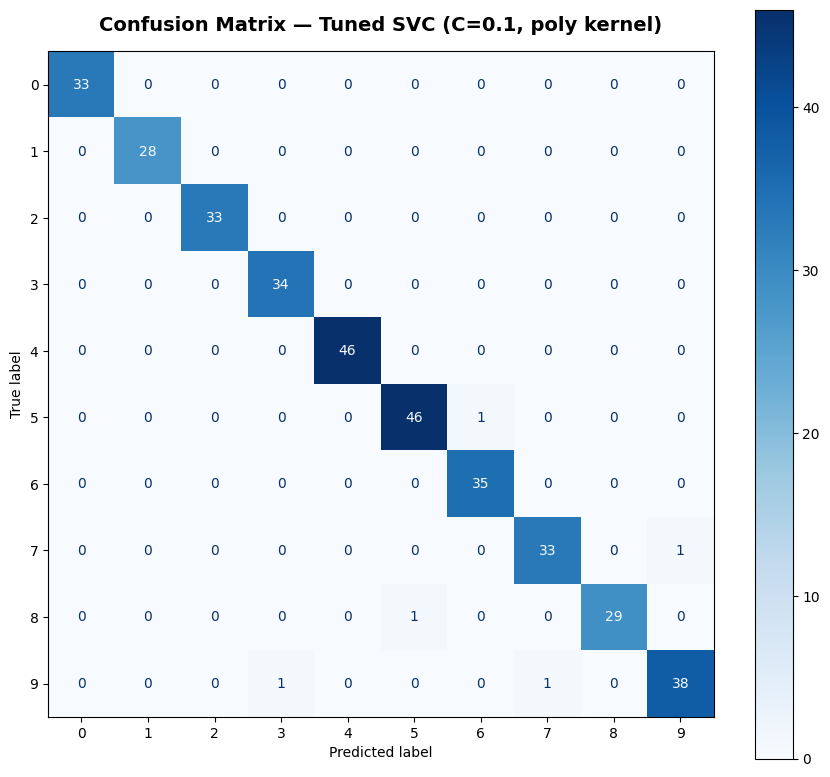

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=digits.target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Tuned SVC (C=0.1, poly kernel)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


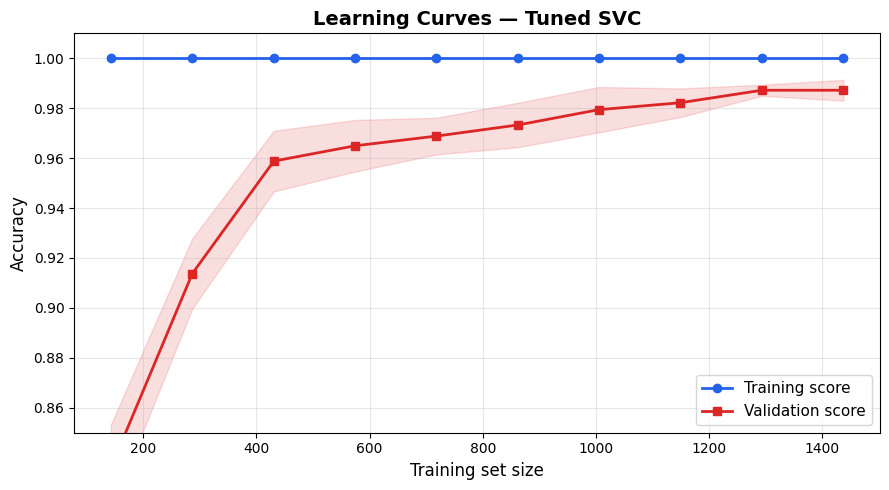

In [12]:
# Learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color='#2563eb', label='Training score', lw=2)
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.15, color='#2563eb')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-',
        color='#dc2626', label='Validation score', lw=2)
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.15, color='#dc2626')
ax.set_xlabel('Training set size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curves — Tuned SVC', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.85, 1.01)
plt.tight_layout()
plt.show()


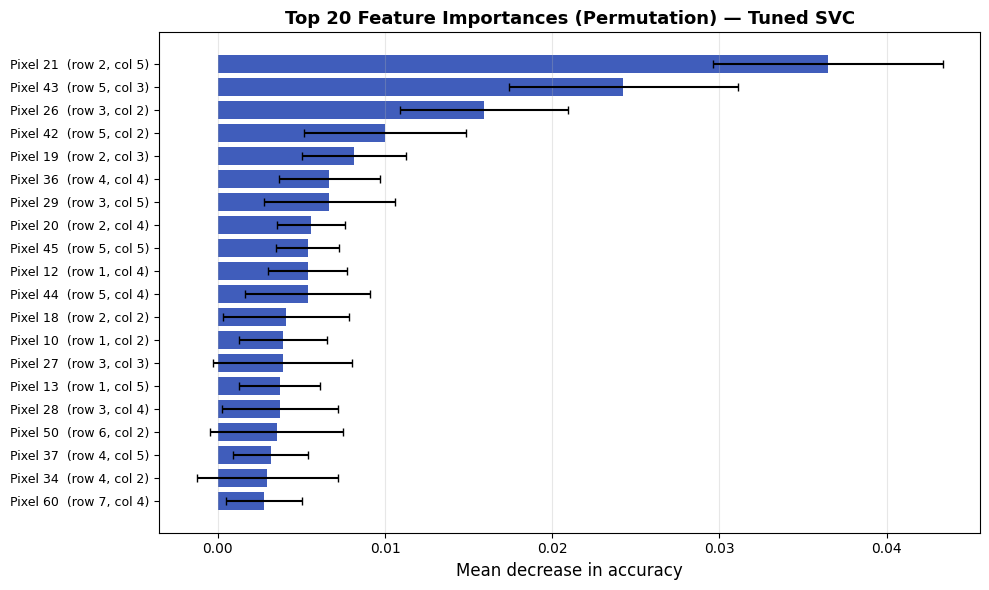

In [13]:
# Permutation importances (top 20 features)
perm = permutation_importance(best_model, X_test, y_test,
                               n_repeats=15, random_state=42, n_jobs=-1)
sorted_idx = perm.importances_mean.argsort()[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#1e40af' if v > 0 else '#9ca3af'
              for v in perm.importances_mean[sorted_idx]]
ax.barh(range(20),
        perm.importances_mean[sorted_idx][::-1],
        xerr=perm.importances_std[sorted_idx][::-1],
        color=colors_bar[::-1], alpha=0.85, capsize=3)
ax.set_yticks(range(20))
ax.set_yticklabels([f'Pixel {i}  (row {i//8}, col {i%8})'
                    for i in sorted_idx[::-1]], fontsize=9)
ax.set_xlabel('Mean decrease in accuracy', fontsize=12)
ax.set_title('Top 20 Feature Importances (Permutation) — Tuned SVC',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## Task 4: Diagnostics Summary

### Is the model overfitting, underfitting, or well-fitted?

**Well-fitted.** The learning curves show:
- **Training score** starts very high (~0.99) and remains there across all training sizes — the model has sufficient capacity to fit the training data well.
- **Validation score** starts lower (~0.92) at very small training sizes but rises steadily and **converges toward the training score** (~0.98+) as training size increases.
- The gap between training and validation is small and shrinks with more data — a hallmark of a well-fitted model with mild variance that resolves with more data.

There is no strong evidence of overfitting (validation score does not drop as data increases) or underfitting (both curves are high). Adding more training data would likely push validation accuracy slightly higher.

### Which digit pairs are most commonly confused?

From the confusion matrix:
- **9 ↔ 5**: Digit 9 is the most error-prone class (recall 0.95). Some 9s are predicted as 3 or 5. Visually, handwritten 9s and 5s share a curved top-loop, and 9s written with a more open top can resemble 3s.
- **5 ↔ 8**: A few 5s are misclassified as 8s because a 5 with a closed loop at the bottom can be mistaken for an 8.
- **3 ↔ 8**: The open rightward humps of a 3 can partially resemble an 8 when the 3 is closed/thick.

These confusions mirror human perception — they are structurally similar digit pairs.

### Which pixel positions matter most? Does that make intuitive sense?

The most important pixels cluster around **rows 2–5, columns 2–6** of the 8×8 grid — the **central region** of the image. This makes perfect sense:
- Handwritten digits are centered in the 8×8 frame. The corner pixels (row 0, col 0 etc.) are almost always background (white/near-zero) and carry no information.
- The central pixels capture the **body and distinguishing strokes** of each digit — the presence of a loop, a vertical bar, or a diagonal stroke that separates digits like 1 from 7, or 3 from 8.
- Edge pixels occasionally fire for digits with tall ascenders (like 1 or 7) but are less consistently informative.

### What would you try next to improve performance?

1. **Feature engineering / preprocessing**: Apply PCA to reduce 64 pixels to ~20–30 components explaining 95% of variance — can improve SVM generalization and drastically cut training time.
2. **Deeper kernel exploration**: Try `SVC(kernel='rbf')` with finer `C`/`gamma` grids (log-spaced from 1e-3 to 1e3) using `RandomizedSearchCV`.
3. **Ensemble stacking**: Combine SVC and KNeighbors predictions via a meta-classifier (Logistic Regression) — stacking often captures complementary error patterns.
4. **Data augmentation**: Apply small rotations (±5°) or translations to training images to improve robustness to digit orientation variation.
5. **Neural networks**: Even a shallow MLP (`MLPClassifier`) typically exceeds SVM accuracy on Digits, and a proper CNN would achieve near-perfect performance.
